Self-Attention

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
from scipy.fft import rfft, rfftfreq
from scipy.ndimage import gaussian_filter1d


In [2]:
df_logs = pd.read_parquet("logs.parquet")

print("\n--- APERÇU DES DONNÉES ---")
print(df_logs.head())

print("\n--- DIMENSIONS ---")
print(f"Lignes : {df_logs.shape[0]}")
print(f"Colonnes : {df_logs.shape[1]}")

print("\n--- COLONNES ---")
print(df_logs.columns.tolist())

print("\n--- TYPES DE DONNÉES ---")
print(df_logs.dtypes)

print("\n--- VALEURS MANQUANTES ---")
print(df_logs.isna().sum())

print("\n--- STATISTIQUES DESCRIPTIVES ---")
print(df_logs.describe(include="all"))

df_tops = pd.read_parquet("tops.parquet")

print("\n--- APERÇU DES DONNÉES ---")
print(df_tops.head())

print("\n--- DIMENSIONS ---")
print(f"Lignes : {df_tops.shape[0]}")
print(f"Colonnes : {df_tops.shape[1]}")

print("\n--- COLONNES ---")
print(df_tops.columns.tolist())

print("\n--- TYPES DE DONNÉES ---")
print(df_tops.dtypes)

print("\n--- VALEURS MANQUANTES ---")
print(df_tops.isna().sum())

print("\n--- STATISTIQUES DESCRIPTIVES ---")
print(df_tops.describe(include="all"))


--- APERÇU DES DONNÉES ---
      wellName  DEPTH        GR
1  512320698.0  421.0   96.9752
2  512320698.0  421.5  102.3324
3  512320698.0  422.0  104.6432
4  512320698.0  422.5   99.2187
5  512320698.0  423.0   92.0200

--- DIMENSIONS ---
Lignes : 7698162
Colonnes : 3

--- COLONNES ---
['wellName', 'DEPTH', 'GR']

--- TYPES DE DONNÉES ---
wellName    float64
DEPTH       float64
GR          float64
dtype: object

--- VALEURS MANQUANTES ---
wellName    0
DEPTH       0
GR          0
dtype: int64

--- STATISTIQUES DESCRIPTIVES ---
           wellName         DEPTH            GR
count  7.698162e+06  7.698162e+06  7.698162e+06
mean   5.123274e+08  3.726369e+03  7.280153e+01
std    3.354847e+03  1.859567e+03  5.715067e+02
min    5.123207e+08  1.000000e+00 -9.999000e+03
25%    5.123250e+08  2.120500e+03  9.269270e+01
50%    5.123267e+08  3.724500e+03  1.028935e+02
75%    5.123305e+08  5.328000e+03  1.136231e+02
max    5.123363e+08  8.940500e+03  2.052933e+03

--- APERÇU DES DONNÉES ---
      

In [24]:
df_logs = df_logs.sort_values(by=['wellName', 'DEPTH']).reset_index(drop=True)
#df_logs.loc[df_logs['GR'] < 0, 'GR'] = pd.NA
#df_logs.loc[df_logs['GR'] > 400, 'GR'] = pd.NA
df_logs['GR'] = df_logs['GR'].clip(lower=0, upper=400)
df_logs = df_logs.dropna(subset=['GR'])
df_tops = df_tops.reset_index()

In [4]:
def get_log_normalized(well):
    sub = df_logs[df_logs['wellName'] == well]
    if sub.empty:
        print(f"⚠️ Aucun log trouvé pour le puits {well}")
        return np.array([]), np.array([])
    
    gr = sub['GR'].values.astype(float)
    depth = sub['DEPTH'].values.astype(float)
    
    # Normalisation min-max
    gr_norm = (gr - gr.min()) / (gr.max() - gr.min())
    
    return gr_norm, depth

In [25]:

def channel_raw(x, weight=1.0):
    """
    Canal brut pondéré.
    x: 1D numpy array
    weight: multiplicative weight (float)
    returns: 1D numpy array same shape as x
    """
    x = np.asarray(x, dtype=np.float32)
    return (weight * x).astype(np.float32)


def channel_gaussian_smooth(x, sigma, mode='reflect', truncate=4.0):
    """
    Lissage gaussien 1D.
    sigma: écart-type du noyau (float)
    mode: bord ('reflect','nearest','constant','mirror','wrap')
    truncate: tronque le noyau à truncate * sigma (float)
    returns: 1D numpy array lissée
    """
    x = np.asarray(x, dtype=np.float32)
    return gaussian_filter1d(x, sigma=sigma, order=0, mode=mode, truncate=truncate).astype(np.float32)


def channel_gaussian_derivative(x, sigma, order=1, mode='reflect', truncate=4.0, delta=1.0):
    """
    Dérivée lissée via convolution avec la dérivée d'un noyau gaussien.
    order: 1 pour dérivée première, 2 pour dérivée seconde, etc.
    delta: intervalle d'échantillonnage (par défaut 1.0)
    returns: 1D numpy array (dérivée lissée)
    """
    x = np.asarray(x, dtype=np.float32)
    # gaussian_filter1d with order>0 computes derivative scaled by 1/delta**order
    return gaussian_filter1d(x, sigma=sigma, order=order, mode=mode, truncate=truncate, output=np.float32) / (delta ** order)


# --- Conventions pour 3 échelles (exemples) ---
# On fournit des wrappers explicites pour les trois échelles demandées.
def channel_smooth_s1(x, sigma1, **kwargs):
    """Lissage gaussien échelle 1 (sigma1)."""
    return channel_gaussian_smooth(x, sigma=sigma1, **kwargs)

def channel_deriv_s1(x, sigma1, **kwargs):
    """Dérivée première lissée échelle 1 (sigma1)."""
    return channel_gaussian_derivative(x, sigma=sigma1, order=1, **kwargs)

def channel_smooth_s2(x, sigma2, **kwargs):
    """Lissage gaussien échelle 2 (sigma2)."""
    return channel_gaussian_smooth(x, sigma=sigma2, **kwargs)

def channel_deriv_s2(x, sigma2, **kwargs):
    """Dérivée première lissée échelle 2 (sigma2)."""
    return channel_gaussian_derivative(x, sigma=sigma2, order=1, **kwargs)

def channel_smooth_s3(x, sigma3, **kwargs):
    """Lissage gaussien échelle 3 (sigma3)."""
    return channel_gaussian_smooth(x, sigma=sigma3, **kwargs)

def channel_deriv_s3(x, sigma3, **kwargs):
    """Dérivée première lissée échelle 3 (sigma3)."""
    return channel_gaussian_derivative(x, sigma=sigma3, order=1, **kwargs)


# ----------------- Exemple d'assemblage en vecteur multi‑canal -----------------
def build_7_channels(x, sigmas=(2.0, 4.0, 8.0), raw_weight=0.5, mode='reflect', truncate=4.0):
    """
    Construit les 7 canaux dans l'ordre :
      [raw*weight,
       smooth(s1), deriv(s1),
       smooth(s2), deriv(s2),
       smooth(s3), deriv(s3)]

    Puis normalise chaque canal séparément :
      moyenne = 0
      écart-type = 1

    returns: numpy array shape (len(x), 7)
    """
    if len(sigmas) != 3:
        raise ValueError("sigmas must be a tuple/list of 3 values")

    x = np.asarray(x, dtype=np.float32)

    s1, s2, s3 = sigmas

    c0 = channel_raw(x, weight=raw_weight)
    c1 = channel_smooth_s1(x, s1, mode=mode, truncate=truncate)
    c2 = channel_deriv_s1(x, s1, mode=mode, truncate=truncate)
    c3 = channel_smooth_s2(x, s2, mode=mode, truncate=truncate)
    c4 = channel_deriv_s2(x, s2, mode=mode, truncate=truncate)
    c5 = channel_smooth_s3(x, s3, mode=mode, truncate=truncate)
    c6 = channel_deriv_s3(x, s3, mode=mode, truncate=truncate)

    X = np.stack([c0, c1, c2, c3, c4, c5, c6], axis=1).astype(np.float32)

    # Normalisation canal par canal
    mean = X.mean(axis=0, keepdims=True)
    std = X.std(axis=0, keepdims=True)

    X = (X - mean) / (std + 1e-8)

    return X.astype(np.float32)

In [35]:
def dtw_with_band(x, y, w=500):
    """
    DTW avec bande de Sakoe–Chiba de largeur w.
    x, y : séries nD
    w : largeur de la bande (en nombre d'échantillons)
    """
    n, m = len(x), len(y)
    
    # Bande maximale : on ne peut pas dépasser les dimensions
    w = max(w, abs(n - m))

    # Matrice de coût cumulée initialisée à +inf
    D = np.full((n, m), np.inf)
    cost = np.full((n, m), np.inf)
    
    # Initialisation
    D[0, 0] = np.linalg.norm(x[0] - y[0])
    
    # Calcul dans la bande
    for i in range(1, n):
        # Limites de j dans la bande
        j_start = max(1, i - w)
        j_end   = min(m, i + w)
        
        for j in range(j_start, j_end):
            cost[i,j] = np.linalg.norm(x[i] - y[j])
            D[i, j] = cost[i,j] + min(
                D[i-1, j],     # vertical
                D[i, j-1],     # horizontal
                D[i-1, j-1]    # diagonal
            )
    
    # Backtracking du chemin
    i, j = n-1, m-1
    path = [(i, j)]
    
    while i > 0 or j > 0:
        candidates = []
        if i > 0 and D[i-1, j] != np.inf:
            candidates.append((D[i-1, j], i-1, j))
        if j > 0 and D[i, j-1] != np.inf:
            candidates.append((D[i, j-1], i, j-1))
        if i > 0 and j > 0 and D[i-1, j-1] != np.inf:
            candidates.append((D[i-1, j-1], i-1, j-1))
        
        if not candidates:
            break
        
        _, i, j = min(candidates)
        path.append((i, j))
    
    path.reverse()
    return D[-1, -1], path,cost

In [36]:
well_A = 512320698.0   # annoté
well_B = 512320973.0   # à prédire

series_A, depth_x = get_log_normalized(well_A)
series_B, depth_y = get_log_normalized(well_B)
    
x = build_7_channels(series_A, sigmas=(2.0, 4.0, 8.0), raw_weight=0.5, mode='reflect', truncate=4.0)
y = build_7_channels(series_B, sigmas=(2.0, 4.0, 8.0), raw_weight=0.5, mode='reflect', truncate=4.0)

In [40]:
dist, path, cost = dtw_with_band(x, y,w=1000)

In [41]:
def predict_top_from_dtw(path, depth_x, depth_y, top_A):
    """
    path : liste de couples (i, j) du DTW
    depth_x : profondeurs du puits A
    depth_y : profondeurs du puits B
    top_A : profondeur du top dans le puits A
    """
    # indice du top dans A
    idx_A = np.argmin(np.abs(depth_x - top_A))
    
    # tous les j alignés avec cet i
    aligned_js = [j for (i, j) in path if i == idx_A]
    if len(aligned_js) == 0:
        return None
    
    idx_B = int(np.mean(aligned_js))
    return depth_y[idx_B]

tops_A = df_tops[df_tops['wellName'] == well_A].iloc[0]

# prédire les tops du puits B
predicted_tops_B = {}
for horizon in ['MARCEL', 'CONRAD', 'SYLVAIN']:
    top_A = tops_A[horizon]
    if not pd.isna(top_A):
        predicted_tops_B[horizon] = predict_top_from_dtw(path, depth_x, depth_y, top_A)
    else:
        predicted_tops_B[horizon] = None

print(predicted_tops_B)

print(df_tops[df_tops['wellName'] == well_B].iloc[0])

{'MARCEL': np.float64(6471.5), 'CONRAD': np.float64(6734.0), 'SYLVAIN': np.float64(6711.5)}
index               6.0
wellName    512320973.0
MARCEL           6466.0
CONRAD           6735.0
SYLVAIN          6688.0
Name: 6, dtype: float64


Sans normalisation : {'MARCEL': np.float32(6472.5), 'CONRAD': np.float32(6735.0), 'SYLVAIN': np.float32(6711.5)}
wellName    512320973.0
MARCEL           6466.0
CONRAD           6735.0
SYLVAIN          6688.0
Name: 6, dtype: float64

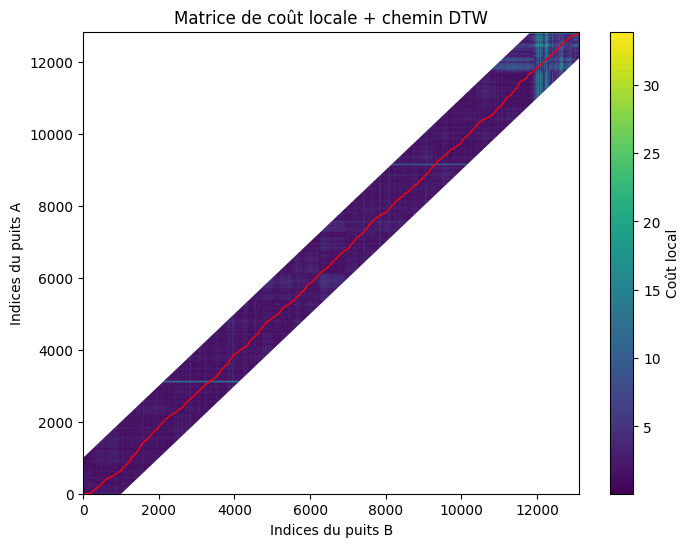

In [42]:
path_i = [p[0] for p in path]
path_j = [p[1] for p in path]

plt.figure(figsize=(8, 6))
plt.imshow(cost, origin="lower", aspect="auto", cmap="viridis")
plt.plot(path_j, path_i, 'r-', linewidth=1)
plt.colorbar(label="Coût local")
plt.xlabel("Indices du puits B")
plt.ylabel("Indices du puits A")
plt.title("Matrice de coût locale + chemin DTW")
plt.show()

In [43]:
# Tous les puits pour lesquels on a des tops
all_wells = df_tops["wellName"].unique()

# On mélange et on en prend 20
np.random.seed(0)  # pour la reproductibilité
selected_wells = np.random.choice(all_wells, size=40, replace=False)

# Puits de référence = le premier
well_A = selected_wells[0]
wells_B = selected_wells[1:40]

print("Puits de référence :", well_A)
print("Puits test :", wells_B)

Puits de référence : 512330153.0
Puits test : [5.12324327e+08 5.12325824e+08 5.12331063e+08 5.12325739e+08
 5.12332887e+08 5.12330130e+08 5.12331895e+08 5.12330330e+08
 5.12325134e+08 5.12326808e+08 5.12329264e+08 5.12325209e+08
 5.12326409e+08 5.12323072e+08 5.12330513e+08 5.12331102e+08
 5.12323910e+08 5.12325491e+08 5.12327285e+08 5.12331862e+08
 5.12331070e+08 5.12327001e+08 5.12325608e+08 5.12331049e+08
 5.12325485e+08 5.12326702e+08 5.12331236e+08 5.12330473e+08
 5.12334023e+08 5.12327004e+08 5.12331288e+08 5.12327287e+08
 5.12322063e+08 5.12324385e+08 5.12333170e+08 5.12323925e+08
 5.12326864e+08 5.12325651e+08 5.12320699e+08]


Attention : ne pas faire tourner ce code, il m'a pris 87 minutes, si vous voulez retenter d'avoir les résultats, inspirez-vous de la partie 2 de ce notebook et prenez 10 minutes pour optimiser plutôt que de le faire tourner 8 fois plus longtemps

In [45]:
results = []

# log du puits de référence
x, depth_x = get_log_normalized(well_A)
tops_A = df_tops[df_tops["wellName"] == well_A].iloc[0]
x = build_7_channels(x, sigmas=(2.0, 4.0, 8.0), raw_weight=0.5, mode='reflect', truncate=4.0)

for well_B in wells_B:
    y, depth_y = get_log_normalized(well_B)
    y = build_7_channels(y, sigmas=(2.0, 4.0, 8.0), raw_weight=0.5, mode='reflect', truncate=4.0)
    
    if len(x) == 0 or len(y) == 0:
        continue  # on saute si pas de log

    # DTW avec bande (ta version maison)
    dist, path, cost = dtw_with_band(x, y, w=1000)

    tops_B_true = df_tops[df_tops["wellName"] == well_B].iloc[0]

    # prédiction + erreurs
    for horizon in ["MARCEL", "CONRAD", "SYLVAIN"]:
        top_A = tops_A[horizon]
        top_B_true = tops_B_true[horizon]

        if pd.isna(top_A) or pd.isna(top_B_true):
            continue

        top_B_pred = predict_top_from_dtw(path, depth_x, depth_y, top_A)
        if top_B_pred is None:
            continue

        err = top_B_pred - top_B_true

        results.append({
            "well": well_B,
            "horizon": horizon,
            "true_depth": top_B_true,
            "pred_depth": top_B_pred,
            "error": err,
            "abs_error": abs(err),
        })

df_errors = pd.DataFrame(results)
df_errors.head()

,well,horizon,true_depth,pred_depth,error,abs_error
0,512324327.0,MARCEL,5938.0,5924.5,-13.5,13.5
1,512324327.0,CONRAD,6218.0,6802.0,584.0,584.0
2,512324327.0,SYLVAIN,6180.0,6777.0,597.0,597.0
3,512325824.0,MARCEL,6298.0,6277.0,-21.0,21.0
4,512325824.0,CONRAD,6549.0,6549.0,0.0,0.0


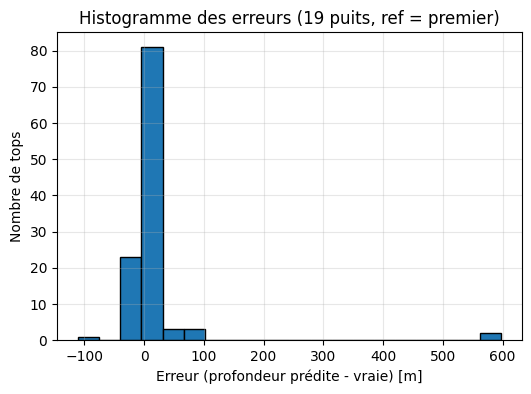

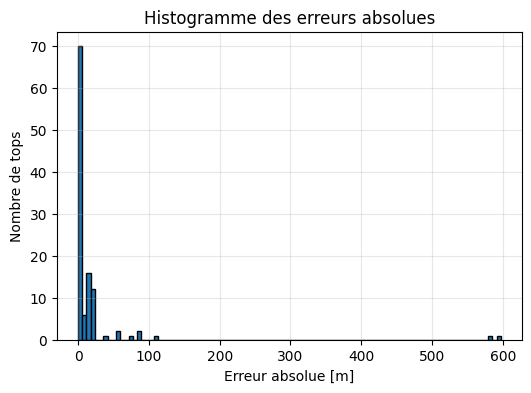

Moyenne abs_error : 20.30
Médiane abs_error : 1.00
MARCEL - moyenne abs error : 16.442307692307693
MARCEL - médiane abs error : 15.5
SYLVAIN - moyenne abs error : 25.807142857142857
SYLVAIN - médiane abs error : 1.0
CONRAD - moyenne abs error : 19.21153846153846
CONRAD - médiane abs error : 0.5


In [46]:
plt.figure(figsize=(6,4))
plt.hist(df_errors["error"], bins=20, edgecolor="k")
plt.xlabel("Erreur (profondeur prédite - vraie) [m]")
plt.ylabel("Nombre de tops")
plt.title("Histogramme des erreurs (19 puits, ref = premier)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df_errors["abs_error"], bins=100, edgecolor="k")
plt.xlabel("Erreur absolue [m]")
plt.ylabel("Nombre de tops")
plt.title("Histogramme des erreurs absolues")
plt.grid(True, alpha=0.3)
plt.show()

# Moyenne
moyenne_abs_error = df_errors['abs_error'].mean()

# Médiane
mediane_abs_error = df_errors['abs_error'].median()

print(f"Moyenne abs_error : {moyenne_abs_error:.2f}")
print(f"Médiane abs_error : {mediane_abs_error:.2f}")

# MARCEL
moyenne_abs_error_MARCEL = df_errors[df_errors["horizon"] == "MARCEL"]["abs_error"].mean()
mediane_abs_error_MARCEL = df_errors[df_errors["horizon"] == "MARCEL"]["abs_error"].median()

# SYLVAIN
moyenne_abs_error_SYLVAIN = df_errors[df_errors["horizon"] == "SYLVAIN"]["abs_error"].mean()
mediane_abs_error_SYLVAIN = df_errors[df_errors["horizon"] == "SYLVAIN"]["abs_error"].median()

# CONRAD
moyenne_abs_error_CONRAD = df_errors[df_errors["horizon"] == "CONRAD"]["abs_error"].mean()
mediane_abs_error_CONRAD = df_errors[df_errors["horizon"] == "CONRAD"]["abs_error"].median()

print("MARCEL - moyenne abs error :", moyenne_abs_error_MARCEL)
print("MARCEL - médiane abs error :", mediane_abs_error_MARCEL)

print("SYLVAIN - moyenne abs error :", moyenne_abs_error_SYLVAIN)
print("SYLVAIN - médiane abs error :", mediane_abs_error_SYLVAIN)

print("CONRAD - moyenne abs error :", moyenne_abs_error_CONRAD)
print("CONRAD - médiane abs error :", mediane_abs_error_CONRAD)

Le fait que ce code ait tourné pendant plus d'une heure donne très envie de tester quelques méthodes simples d'optimisation

In [49]:
from numba import njit
from joblib import Parallel, delayed

On passe à de la "self-attention" en plus, on rajoute des canaux de contexte qui font une somme pondérés pour chaque points des points proches, l'idée est de "débruiter"/exploiter le caractère corrélé de la série, on espère améliorer précision comme rugosité.
La self-attention locale déterministe calcule, pour chaque point \(i\), un contexte \(c_i\) à partir des points voisins \(j \in \mathcal{N}(i)\). Les poids d'attention sont définis par :

$$
s_{ij}
=
\frac{\gamma}{\sqrt{C}} X_i^\top X_j
-
\frac{(i-j)^2}{2\sigma^2}
$$

$$
a_{ij}
=
\frac{\exp(s_{ij})}
{\sum\limits_{k \in \mathcal{N}(i)} \exp(s_{ik})}
$$

$$
c_i
=
\sum_{j \in \mathcal{N}(i)} a_{ij} X_j
$$

La représentation finale utilisée par le DTW est :

$$
Z_i = [X_i,\alpha c_i]
$$


In [47]:
# Paramètres des features
SIGMAS = (2.0, 4.0, 8.0)
RAW_WEIGHT = 0.5

# Paramètres self-attention locale
RADIUS = 200
SIGMA_POS = 100.0
ATTN_GAIN = 2.0
ATTN_ALPHA = 0.5

# Paramètre DTW
W_DTW = 1000

# Nombre de cœurs utilisés pour les puits
# Commence par 4. Si ta RAM tient bien, augmente.
N_JOBS = 4

HORIZONS = ["MARCEL", "CONRAD", "SYLVAIN"]

In [50]:
@njit(fastmath=True, nogil=True)
def local_self_attention_core(Xn, radius, attn_gain, attn_alpha, sigma_pos):
    """
    Self-attention locale déterministe compilée avec Numba.

    Xn : array (L, C), déjà normalisé canal par canal.
    Retour : Z (L, 2C) = [Xn, attn_alpha * contexte]
    """
    L, C = Xn.shape
    context = np.empty((L, C), dtype=np.float32)

    scale = attn_gain / np.sqrt(C)

    for i in range(L):
        j0 = max(0, i - radius)
        j1 = min(L, i + radius + 1)
        W = j1 - j0

        scores = np.empty(W, dtype=np.float32)

        # Calcul scores + biais positionnel
        max_score = -1e30

        for t in range(W):
            j = j0 + t

            dot = 0.0
            for c in range(C):
                dot += Xn[i, c] * Xn[j, c]

            d = j - i
            pos_bias = - (d * d) / (2.0 * sigma_pos * sigma_pos)

            s = scale * dot + pos_bias
            scores[t] = s

            if s > max_score:
                max_score = s

        # Softmax stable
        sum_exp = 0.0

        for t in range(W):
            val = np.exp(scores[t] - max_score)
            scores[t] = val
            sum_exp += val

        # Contexte attentionnel
        for c in range(C):
            acc = 0.0

            for t in range(W):
                j = j0 + t
                weight = scores[t] / (sum_exp + 1e-12)
                acc += weight * Xn[j, c]

            context[i, c] = acc

    # Concaténation [features locales, contexte]
    Z = np.empty((L, 2 * C), dtype=np.float32)

    for i in range(L):
        for c in range(C):
            Z[i, c] = Xn[i, c]
            Z[i, C + c] = attn_alpha * context[i, c]

    return Z

In [51]:
def local_self_attention_fast(
    X,
    radius=200,
    attn_gain=2.0,
    attn_alpha=0.5,
    sigma_pos=100.0,
    normalize_input=True,
    normalize_output=True
):
    """
    Wrapper Python autour du cœur Numba.
    """
    X = np.asarray(X, dtype=np.float32)

    if X.ndim != 2:
        raise ValueError("X doit être une matrice de shape (L, C).")

    if len(X) == 0:
        return X

    if normalize_input:
        Xn = (X - X.mean(axis=0, keepdims=True)) / (X.std(axis=0, keepdims=True) + 1e-8)
    else:
        Xn = X.copy()

    Xn = np.ascontiguousarray(Xn, dtype=np.float32)

    Z = local_self_attention_core(
        Xn,
        int(radius),
        float(attn_gain),
        float(attn_alpha),
        float(sigma_pos)
    )

    if normalize_output:
        Z = (Z - Z.mean(axis=0, keepdims=True)) / (Z.std(axis=0, keepdims=True) + 1e-8)

    return np.ascontiguousarray(Z, dtype=np.float32)

In [52]:
def build_features_attention_fast(
    x,
    sigmas=(2.0, 4.0, 8.0),
    raw_weight=0.5,
    mode="reflect",
    truncate=4.0,
    radius=200,
    attn_gain=2.0,
    attn_alpha=0.5,
    sigma_pos=100.0
):
    """
    Signal brut -> 7 canaux CNN fixes -> self-attention locale déterministe.

    Retour :
        Z : shape (len(x), 14)
    """

    X = build_7_channels(
        x,
        sigmas=sigmas,
        raw_weight=raw_weight,
        mode=mode,
        truncate=truncate
    )

    Z = local_self_attention_fast(
        X,
        radius=radius,
        attn_gain=attn_gain,
        attn_alpha=attn_alpha,
        sigma_pos=sigma_pos,
        normalize_input=True,
        normalize_output=True
    )

    return Z

In [53]:
@njit(fastmath=True, nogil=True)
def dtw_banded_path_core(X, Y, w):
    """
    DTW multivarié bandé, avec stockage compact de la bande.

    X : shape (n, d)
    Y : shape (m, d)
    w : rayon de bande

    Retour :
        dist : coût DTW final
        path : array shape (K, 2)
    """

    n, d = X.shape
    m = Y.shape[0]

    B = 2 * w + 1
    INF = 1e30

    # Si la fin (n,m) est hors bande, aucun chemin possible
    final_b = m - n + w
    if final_b < 0 or final_b >= B:
        empty_path = np.empty((0, 2), dtype=np.int32)
        return INF, empty_path

    # D[i, b] représente D[i, j] avec b = j - i + w
    D = np.full((n + 1, B), INF, dtype=np.float32)

    # P stocke le prédécesseur :
    # 0 = diagonale, 1 = haut, 2 = gauche, 255 = invalide
    P = np.full((n + 1, B), 255, dtype=np.uint8)

    # Point de départ D[0,0]
    # Pour i=0, j=0 donne b = 0 - 0 + w = w
    D[0, w] = 0.0

    for i in range(1, n + 1):
        jlo = max(1, i - w)
        jhi = min(m, i + w)

        for j in range(jlo, jhi + 1):
            b = j - i + w

            # Coût local : distance euclidienne au carré
            # Plus rapide que sqrt, et suffisant pour le chemin DTW
            cost = 0.0
            for c in range(d):
                diff = X[i - 1, c] - Y[j - 1, c]
                cost += diff * diff

            best = INF
            pred = 255

            # Diagonale : D[i-1, j-1]
            b_diag = b
            if 0 <= b_diag < B:
                val = D[i - 1, b_diag]
                if val < best:
                    best = val
                    pred = 0

            # Haut : D[i-1, j]
            b_up = b + 1
            if 0 <= b_up < B:
                val = D[i - 1, b_up]
                if val < best:
                    best = val
                    pred = 1

            # Gauche : D[i, j-1]
            b_left = b - 1
            if 0 <= b_left < B:
                val = D[i, b_left]
                if val < best:
                    best = val
                    pred = 2

            D[i, b] = cost + best
            P[i, b] = pred

    dist = float(D[n, final_b])

    if dist >= INF / 2:
        empty_path = np.empty((0, 2), dtype=np.int32)
        return INF, empty_path

    # Backtracking
    max_len = n + m + 1
    tmp_i = np.empty(max_len, dtype=np.int32)
    tmp_j = np.empty(max_len, dtype=np.int32)

    i = n
    j = m
    k = 0

    while i > 0 and j > 0:
        b = j - i + w

        if b < 0 or b >= B:
            break

        tmp_i[k] = i - 1
        tmp_j[k] = j - 1
        k += 1

        pred = P[i, b]

        if pred == 0:
            i -= 1
            j -= 1
        elif pred == 1:
            i -= 1
        elif pred == 2:
            j -= 1
        else:
            break

    path = np.empty((k, 2), dtype=np.int32)

    for t in range(k):
        path[t, 0] = tmp_i[k - 1 - t]
        path[t, 1] = tmp_j[k - 1 - t]

    return dist, path

In [54]:
def dtw_with_band_fast(X, Y, w=1000):
    """
    Wrapper rapide du DTW bandé.

    Retour :
        dist : coût DTW
        path_arr : array shape (K, 2)
    """
    X = np.ascontiguousarray(X, dtype=np.float32)
    Y = np.ascontiguousarray(Y, dtype=np.float32)

    dist, path_arr = dtw_banded_path_core(X, Y, int(w))

    return dist, path_arr

In [55]:
def predict_top_from_path_array(path_arr, depth_x, depth_y, top_A):
    """
    Projette un top du puits A vers le puits B via le chemin DTW.

    path_arr : array (K, 2)
        Colonne 0 = indices dans A
        Colonne 1 = indices dans B
    """

    if path_arr is None or len(path_arr) == 0:
        return None

    depth_x = np.asarray(depth_x)
    depth_y = np.asarray(depth_y)

    # Indice du top dans le puits A
    i_top = int(np.argmin(np.abs(depth_x - top_A)))

    # Tous les indices B associés à ce i_top
    mask = path_arr[:, 0] == i_top

    if not np.any(mask):
        return None

    j_vals = path_arr[mask, 1]

    # On prend la moyenne si plusieurs j sont associés au même i
    j_mean = int(round(np.mean(j_vals)))

    if j_mean < 0 or j_mean >= len(depth_y):
        return None

    return float(depth_y[j_mean])

In [56]:
def process_one_well_attention_fast(
    well_B,
    x_feat,
    depth_x,
    tops_A,
    tops_indexed,
    w_dtw=1000,
    radius=200,
    sigma_pos=100.0,
    attn_gain=2.0,
    attn_alpha=0.5
):
    """
    Traite un puits cible :
    - charge son log
    - construit features CNN + attention
    - lance DTW rapide
    - prédit les tops
    - retourne une liste de résultats
    """

    local_results = []

    if well_B not in tops_indexed.index:
        return local_results

    y_raw, depth_y = get_log_normalized(well_B)

    if len(y_raw) == 0:
        return local_results

    y_feat = build_features_attention_fast(
        y_raw,
        sigmas=SIGMAS,
        raw_weight=RAW_WEIGHT,
        mode="reflect",
        truncate=4.0,
        radius=radius,
        attn_gain=attn_gain,
        attn_alpha=attn_alpha,
        sigma_pos=sigma_pos
    )

    if len(y_feat) == 0:
        return local_results

    dist, path_arr = dtw_with_band_fast(x_feat, y_feat, w=w_dtw)

    if len(path_arr) == 0:
        return local_results

    tops_B_true = tops_indexed.loc[well_B]

    for horizon in HORIZONS:
        top_A = tops_A[horizon]
        top_B_true = tops_B_true[horizon]

        if pd.isna(top_A) or pd.isna(top_B_true):
            continue

        top_B_pred = predict_top_from_path_array(
            path_arr,
            depth_x,
            depth_y,
            top_A
        )

        if top_B_pred is None:
            continue

        err = top_B_pred - top_B_true

        local_results.append({
            "well": well_B,
            "horizon": horizon,
            "true_depth": top_B_true,
            "pred_depth": top_B_pred,
            "error": err,
            "abs_error": abs(err),
            "dtw_dist": dist,
        })

    return local_results

In [57]:
# Index rapide pour les tops
tops_indexed = df_tops.set_index("wellName", drop=False)

# Préparation du puits de référence
x_raw, depth_x = get_log_normalized(well_A)
tops_A = tops_indexed.loc[well_A]

x_feat = build_features_attention_fast(
    x_raw,
    sigmas=SIGMAS,
    raw_weight=RAW_WEIGHT,
    mode="reflect",
    truncate=4.0,
    radius=RADIUS,
    attn_gain=ATTN_GAIN,
    attn_alpha=ATTN_ALPHA,
    sigma_pos=SIGMA_POS
)

# Compilation Numba à blanc pour éviter que le premier puits paie tout le coût
_dummy_X = np.random.rand(30, 14).astype(np.float32)
_dummy_Y = np.random.rand(32, 14).astype(np.float32)

_ = local_self_attention_core(
    _dummy_X[:, :7],
    3,
    2.0,
    0.5,
    2.0
)

_ = dtw_banded_path_core(
    _dummy_X,
    _dummy_Y,
    5
)

# Parallélisation par puits cible
all_results_nested = Parallel(
    n_jobs=N_JOBS,
    backend="threading",
    verbose=10
)(
    delayed(process_one_well_attention_fast)(
        well_B,
        x_feat,
        depth_x,
        tops_A,
        tops_indexed,
        w_dtw=W_DTW,
        radius=RADIUS,
        sigma_pos=SIGMA_POS,
        attn_gain=ATTN_GAIN,
        attn_alpha=ATTN_ALPHA
    )
    for well_B in wells_B
)

# Aplatir la liste
results_attention_fast = [
    item
    for sublist in all_results_nested
    for item in sublist
]

df_errors_attention_fast = pd.DataFrame(results_attention_fast)

df_errors_attention_fast.head()

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    1.5s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    2.3s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:    3.6s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:    4.4s
[Parallel(n_jobs=4)]: Done  36 out of  39 | elapsed:    6.0s remaining:    0.4s
[Parallel(n_jobs=4)]: Done  39 out of  39 | elapsed:    6.6s finished


,well,horizon,true_depth,pred_depth,error,abs_error,dtw_dist
0,512324327.0,MARCEL,5938.0,5924.5,-13.5,13.5,113402.632812
1,512324327.0,CONRAD,6218.0,6802.0,584.0,584.0,113402.632812
2,512324327.0,SYLVAIN,6180.0,6777.5,597.5,597.5,113402.632812
3,512325824.0,MARCEL,6298.0,6277.0,-21.0,21.0,35906.085938
4,512325824.0,CONRAD,6549.0,6549.0,0.0,0.0,35906.085938


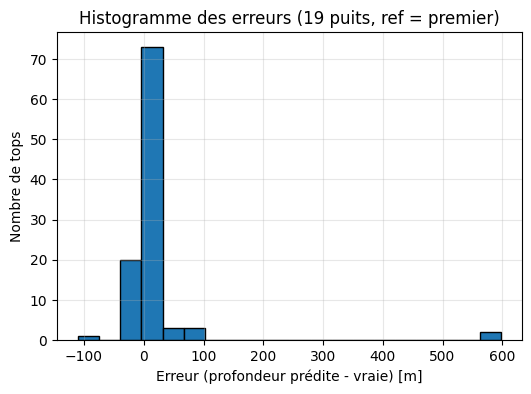

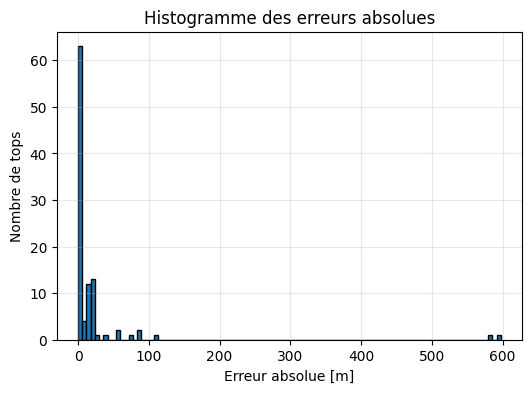

Moyenne abs error globale : 22.083333333333332
Médiane abs error globale : 1.25
MARCEL - moyenne abs error : 17.17142857142857
MARCEL - médiane abs error : 15.5
SYLVAIN - moyenne abs error : 28.1875
SYLVAIN - médiane abs error : 1.5
CONRAD - moyenne abs error : 21.414285714285715
CONRAD - médiane abs error : 0.5


In [59]:
plt.figure(figsize=(6,4))
plt.hist(df_errors_attention_fast["error"], bins=20, edgecolor="k")
plt.xlabel("Erreur (profondeur prédite - vraie) [m]")
plt.ylabel("Nombre de tops")
plt.title("Histogramme des erreurs (19 puits, ref = premier)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df_errors_attention_fast["abs_error"], bins=100, edgecolor="k")
plt.xlabel("Erreur absolue [m]")
plt.ylabel("Nombre de tops")
plt.title("Histogramme des erreurs absolues")
plt.grid(True, alpha=0.3)
plt.show()

moyenne_abs_error = df_errors_attention_fast["abs_error"].mean()
mediane_abs_error = df_errors_attention_fast["abs_error"].median()

print("Moyenne abs error globale :", moyenne_abs_error)
print("Médiane abs error globale :", mediane_abs_error)

moyenne_abs_error_MARCEL = df_errors_attention_fast[df_errors_attention_fast["horizon"] == "MARCEL"]["abs_error"].mean()
mediane_abs_error_MARCEL = df_errors_attention_fast[df_errors_attention_fast["horizon"] == "MARCEL"]["abs_error"].median()

moyenne_abs_error_SYLVAIN = df_errors_attention_fast[df_errors_attention_fast["horizon"] == "SYLVAIN"]["abs_error"].mean()
mediane_abs_error_SYLVAIN = df_errors_attention_fast[df_errors_attention_fast["horizon"] == "SYLVAIN"]["abs_error"].median()

moyenne_abs_error_CONRAD = df_errors_attention_fast[df_errors_attention_fast["horizon"] == "CONRAD"]["abs_error"].mean()
mediane_abs_error_CONRAD = df_errors_attention_fast[df_errors_attention_fast["horizon"] == "CONRAD"]["abs_error"].median()

print("MARCEL - moyenne abs error :", moyenne_abs_error_MARCEL)
print("MARCEL - médiane abs error :", mediane_abs_error_MARCEL)

print("SYLVAIN - moyenne abs error :", moyenne_abs_error_SYLVAIN)
print("SYLVAIN - médiane abs error :", mediane_abs_error_SYLVAIN)

print("CONRAD - moyenne abs error :", moyenne_abs_error_CONRAD)
print("CONRAD - médiane abs error :", mediane_abs_error_CONRAD)